# Core Operations: Sprinkling and Causal Relations

This notebook focuses on the geometry step (sprinkling) and how causal
relations are computed from spacetime coordinates.

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd()
if (cwd / "src").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise RuntimeError("Could not locate project root (expected a src/ folder).")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

## Sprinkling
We generate $N$ points uniformly in a 2D causal diamond. The time coordinate
is sorted so later algorithms can assume a time-ordered set.

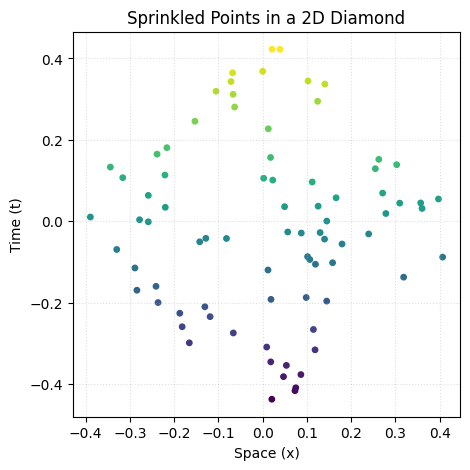

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from src.core_operations import sprinkle

N = 80
points = sprinkle(N, dim=2)

plt.figure(figsize=(5, 5))
plt.scatter(points[:, 1], points[:, 0], s=15, c=points[:, 0], cmap="viridis")
plt.xlabel("Space (x)")
plt.ylabel("Time (t)")
plt.title("Sprinkled Points in a 2D Diamond")
plt.grid(True, linestyle=":", alpha=0.4)
plt.show()

## Causal Matrix
The causal matrix $R$ encodes relations: $R[i,j]=1$ when point $i$ is in the
causal past of point $j$. We can measure how many relations exist.

In [3]:
from src.core_operations import causal_matrix

R = causal_matrix(points, dim=2)
num_relations = int(np.sum(R))
total_pairs = N * (N - 1)
print(f"Relations: {num_relations} / {total_pairs}")
print(f"Density: {num_relations / total_pairs:.3f}")

Relations: 1700 / 6320
Density: 0.269


## Hasse Edges
The Hasse diagram draws only the covering relations (transitive reduction).
This makes the causal set easier to interpret visually.

In [4]:
from src.visualization import hasse_edges_from_R

edges = hasse_edges_from_R(R)
print(f"Hasse edges: {len(edges)}")
print("First 10 edges:", edges[:10])

Hasse edges: 219
First 10 edges: [(0, 3), (0, 7), (0, 10), (0, 13), (0, 14), (0, 22), (1, 2), (1, 3), (1, 10), (2, 4)]
